In [ ]:
!pip install dlib opencv-python scipy matplotlib

In [ ]:
import os

os.makedirs("frontalization_models", exist_ok=True)
os.makedirs("dlib_models", exist_ok=True)

In [ ]:
import shutil

shutil.move("model3Ddlib.mat", "frontalization_models/model3Ddlib.mat")
shutil.move("eyemask.mat", "frontalization_models/eyemask.mat")

'frontalization_models/eyemask.mat'

In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat dlib_models/

--2026-04-15 09:03:26--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-15 09:03:26--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  37.7MB/s    in 1.6s    

2026-04-15 09:03:28 (37.7 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



Number of faces detected: 1
query image shape: (250, 250, 3)


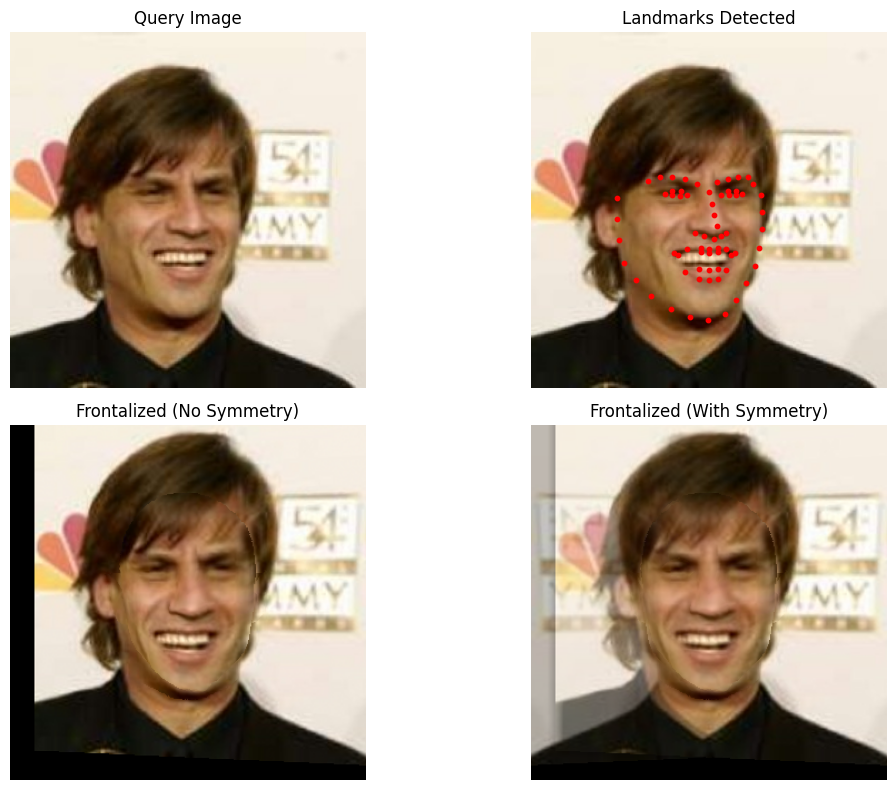

In [ ]:
import frontalize
import facial_feature_detector as feature_detection
import camera_calibration as calib
import scipy.io as io
import cv2
import numpy as np
import os
import check_resources as check
import matplotlib.pyplot as plt

# IMPORTANT for Colab
%matplotlib inline

this_path = "/content"

def demo():
    # Step 1: Ensure dlib model exists
    check.check_dlib_landmark_weights()

    # Step 2: Load 3D model
    model3D = frontalize.ThreeD_Model(
        os.path.join(this_path, "frontalization_models/model3Ddlib.mat"),
        'model_dlib'
    )

    # Step 3: Load image
    img_path = os.path.join(this_path, "test.jpg")
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not found. Check path!")

    # Convert BGR → RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 4: Detect landmarks
    lmarks = feature_detection.get_landmarks(img)

    if len(lmarks) == 0:
        raise ValueError("No face detected!")

    # Step 5: Camera calibration
    proj_matrix, camera_matrix, rmat, tvec = calib.estimate_camera(model3D, lmarks[0])

    # Step 6: Load eyemask
    eyemask = np.asarray(
        io.loadmat(os.path.join(this_path, "frontalization_models/eyemask.mat"))['eyemask']
    )

    # Step 7: Frontalization
    frontal_raw, frontal_sym = frontalize.frontalize(
        img, proj_matrix, model3D.ref_U, eyemask
    )

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12, 8))

    # Original Image
    plt.subplot(2, 2, 1)
    plt.title("Query Image")
    plt.imshow(img_rgb)
    plt.axis('off')

    # Landmarks
    plt.subplot(2, 2, 2)
    plt.title("Landmarks Detected")
    plt.imshow(img_rgb)
    plt.scatter(lmarks[0][:, 0], lmarks[0][:, 1], c='red', s=10)
    plt.axis('off')

    # Frontal Raw
    plt.subplot(2, 2, 3)
    plt.title("Frontalized (No Symmetry)")
    plt.imshow(frontal_raw[:, :, ::-1])
    plt.axis('off')

    # Frontal Symmetric
    plt.subplot(2, 2, 4)
    plt.title("Frontalized (With Symmetry)")
    plt.imshow(frontal_sym[:, :, ::-1])
    plt.axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    demo()